<b>Group Number:</b> 8
<br><b>Name Group Member 1: Anton Seifert</b> 
<br><b>u-Kürzel Group Member 1: unjud</b> 
<br><b>Name Group Member 2: Arne Segatz</b> 
<br><b>u-Kürzel Group Member 2: urnye</b> 
# 4 Reinforcement Learning with Gymnasium

In [74]:
# Relevant imports for the notebook
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
from IPython import display
import time
from tests.tests import EA_RL_Tests

test = EA_RL_Tests()

## 4.1 Introduction to Reinforcement Learning

**Reinforcement Learning (RL)** is a branch of machine learning that focuses on how agents can learn to make decisions by interacting with an environment. Instead of being trained on labeled data, as in supervised learning, an RL agent learns through trial and error. At each step, the agent takes an action, observes the outcome, and receives feedback in the form of rewards or penalties. Over time, it uses this feedback to improve its behavior. The ultimate goal is to discover an optimal policy, a strategy that allows the agent to maximize its long term cumulative rewards.

RL is particularly powerful in situations where sequential decision making is required. Well known applications include robotics, where robots learn to walk or manipulate objects; game playing, such as AlphaGo defeating world champions; autonomous systems, like self driving cars; and recommendation engines that adapt to user preferences. In all of these cases, the agent must learn not just to act well in the immediate moment, but to plan ahead and balance short term and long term benefits.

To describe an RL problem, it helps to break it down into a few key components. The agent is the learner or decision maker, the entity we want to train. The environment is the external system the agent interacts with, which responds to the agent's actions. At any point, the environment is in a particular state, which represents the current situation the agent perceives. Based on this state, the agent chooses an action from a set of possible decisions. After the action is executed, the environment provides a reward, which is a numerical signal indicating how good or bad that action was in the given situation. By repeatedly going through this cycle of states, actions, and rewards, the agent gradually learns how to act in order to achieve its goal.

<img src="images/RL_diagram.png" alt="rl_loop" width= "800px"/>

## 4.2 Understanding Rewards and Returns

### Rewards (Rₜ)

A reward Rt​ is an immediate numerical feedback signal received after taking an action in a given state. It indicates how good or bad the action was:

- Positive rewards encourage the agent (e.g., for winning a game).

- Negative rewards (or penalties) discourage bad behavior (e.g., for crashing a robot).

Rewards are designed by the problem designer and guide the agent toward desired behavior.
However, they need to be defined with great care, because agents tend to exploit imperfections in the reward signal rather than truly achieving the intended goal.
This issue, often called reward hacking, occurs when the agent discovers loopholes or shortcuts that maximize the numerical reward while failing to produce the desired real world outcome.
For example, a cleaning robot might learn to repeatedly dump and re-clean the same pile of dirt to collect rewards.
Poorly designed rewards can therefore lead to unintended, inefficient, or even harmful behaviors.


### Returns (Gₜ): Total Accumulated Rewards

Since RL focuses on long term success, the agent must consider not just immediate rewards but also future ones. The return Gt​ is the sum of discounted future rewards from time step *t*:

$$
G_t = R_{t+1} + \gamma R_{t+2} + \gamma^2 R_{t+3} + \cdots = \sum_{k=0}^{\infty} \gamma^k R_{t+k+1}
$$

where:
- Discount factor (γ): A value between 0 and 1 that determines how much the agent prioritizes immediate vs. future rewards.
    - γ≈0: The agent cares only about immediate rewards (short sighted).
    - γ≈1: The agent values future rewards almost as much as current ones (long term planning).

- $R_{t}$ is the reward at time $t$

The return is crucial because the agent’s goal is to maximize expected return, not just immediate rewards.

<div class="alert alert-block alert-success">
<b>Task:</b> Implement calculation
<ul>
<li> Complete the function to calculate returns using discounted rewards
<li> Test with different gamma values to see how discounting affects future rewards
</ul>
</div>

In [75]:
def calculate_returns(rewards: list[float], gamma: float) -> list[float]:
    """
    Calculate the discounted returns for a sequence of rewards.
    
    This function computes the cumulative discounted future rewards (returns) for each 
    time step in a sequence of rewards. The return at each time step is the sum of 
    the current reward plus the discounted future rewards.
    
    Args:
        rewards: List of rewards received at each time step
        gamma: Discount factor (0 <= gamma <= 1) that determines the importance of future rewards
    
    Returns:
        List of discounted returns for each time step, rounded to 3 decimal places
    """
    # STUDENT CODE HERE (2 pts)
    G = 0
    returns = []
    for t in range(len(rewards)):
        G = 0
        for k in range(len(rewards)-t):
            G += rewards[t+k]*(gamma**k)
        returns.append(G)



    # STUDENT CODE until HERE

    return [round(r, 3) for r in returns]

rewards = [0, 0, 0, 1]
print("gamma=0.9:", calculate_returns(rewards, 0.9))
print("gamma=0.5:", calculate_returns(rewards, 0.5))

test.test_return_values(calculate_returns)

gamma=0.9: [0.729, 0.81, 0.9, 1.0]
gamma=0.5: [0.125, 0.25, 0.5, 1.0]
Your data looks alright, you can continue with the workbook


## 4.3 The Bellman Equation: Connecting Rewards and Values

Once we understand rewards and returns, we can define value functions, which estimate how good a state or action is in terms of expected return. The Bellman Equation provides a recursive relationship that makes computing these values feasible.

### Value Functions

1. **State-Value Function (V(s))**: The expected return when starting in state *s* and following policy π.

   $$
   V^\pi(s) = \mathbb{E}_\pi[G_t | S_t = s]
   $$

2. **Action-Value Function (Q(s,a))**: The expected return after taking action *a* in state *s* and then following policy π.

   $$
   Q^\pi(s,a) = \mathbb{E}_\pi[G_t | S_t = s, A_t = a]
   $$

### The Bellman Equation for V(s)

The value of a state can be expressed in terms of the immediate reward plus the discounted value of the next state:

$$
V^\pi(s) = \mathbb{E}_\pi \left[ R_{t+1} + \gamma V^\pi(S_{t+1}) \mid S_t = s \right]
$$

- $R_{t+1}$: Immediate reward after leaving state *s*
- $V^\pi(S_{t+1})$: Value of the next state
- $\mathbb{E}_\pi$: Expectation under policy π

This equation is recursive, meaning the value of a state depends on the values of subsequent states.

### Bellman Optimality Equation

For the optimal policy $\pi^*$, the Bellman Optimality Equation ensures the best possible value:

$$
V^*(s) = \max_{a} \mathbb{E}_{\pi^*} \left[ R_{t+1} + \gamma V^*(S_{t+1}) \mid S_t = s, A_t = a \right]
$$

### Why is the Bellman Equation Important?

- It breaks down the complex problem of long term planning into simpler, recursive steps
- It enables Dynamic Programming methods like Value Iteration and Policy Iteration
- It serves as the foundation for many RL algorithms, including Q-Learning and Deep RL

<div class="alert alert-block alert-success">
<b>Task:</b> Implement Bellman update
<ul>
<li> Below, we have defined a 3x3 grid world. Each grid-cell is a state (0 = top left, 8 = bottom right) and you start in state 0. In each state, an action can be taken to go either up, right, down or left. Each step has an immediate reward of -1, except when you step into the terminal cell in the bottom right (state = 8), then the reward will be +10.
<li> You can use the value function V to get the currently known value for a state (v = V[s])
</ul>

Hint: The $\max_{a}$ and expectation $\mathbb{E}_{\pi^*}$ is already covered by the for loop and max_value check. You only need to implement the value calculation for each action.
</div>

In [76]:
# Define a simple 3x3 gridworld
# States: 0-8 (0=top-left, 8=bottom-right)
# Actions: 0=up, 1=right, 2=down, 3=left
# Terminal state: 8 (bottom-right corner)
# Rewards: -1 for each step, +10 at terminal state

# Environment parameters
GRID_SIZE = 3
STATES = GRID_SIZE * GRID_SIZE
ACTIONS = 4
TERMINAL_STATE = 8


def transition(state: int, action: int) -> tuple[int, float]:
    """
    Simulate the transition function for the gridworld environment.
    
    Given a state and action, returns the new state and reward according to
    the gridworld dynamics. Actions move the agent in the grid, with boundaries
    preventing movement outside the grid.
    
    Args:
        state: Current state (0-8)
        action: Action to take (0=up, 1=right, 2=down, 3=left)
    
    Returns:
        tuple: (new_state, reward) where new_state is the resulting state and
               reward is the immediate reward for this transition
    """
    i, j = divmod(state, GRID_SIZE)
    
    if action == 0:  # up
        i = max(i - 1, 0)
    elif action == 1:  # right
        j = min(j + 1, GRID_SIZE - 1)
    elif action == 2:  # down
        i = min(i + 1, GRID_SIZE - 1)
    elif action == 3:  # left
        j = max(j - 1, 0)
    
    new_state = i * GRID_SIZE + j
    reward = -1 if new_state != TERMINAL_STATE else 10
    return new_state, reward

def bellman_update(V: np.ndarray) -> None:
    """
    Perform one iteration of Bellman update for value iteration.
    
    This function updates the value function V using the Bellman optimality equation.
    For each state, it considers all possible actions and updates the state's value
    to be the maximum expected return from that state.
    
    Args:
        V: Current value function array where V[s] represents the value of state s
    """
    for s in range(STATES):
        if s == TERMINAL_STATE:
            continue

        # find the biggest value from all actions taken in state s
        max_value = -np.inf
        for a in range(ACTIONS):
            new_state, reward = transition(s, a)
            gamma = 0  # discount factor

            ## STUDENT CODE HERE (2 pts)
            value = reward+ gamma*V[new_state] #V(state) wird oben mit übergeben


            ## STUDENT CODE until HERE

            if value > max_value:
                max_value = value
        
        V[s] = max_value

value_func = np.zeros(STATES)
for _ in range(4):
    bellman_update(value_func)

print("Value Function:")
print(value_func.reshape((GRID_SIZE, GRID_SIZE)))

test.test_value_function(value_func)

Value Function:
[[-1. -1. -1.]
 [-1. -1. 10.]
 [-1. 10.  0.]]
Your data looks alright, you can continue with the workbook


<div class="alert alert-block alert-success">
<b>Question (2 pt):</b> The entries in the value function show you how "good" each state is under our policy. What can you see in the value function? Why do the values look like this? You can play around with the discount factor (gamma) to see how it impacts the results.
</div>
<div class="alert alert-block alert-success">
<b>Your Answer:</b> The cells next to the goal, always are rated as as a 10 because the next step always land on the goal. There is a direct linkage between the Value and the distance to the goal(the closer, the higher tha value). Only with very low discount facotrs the cells next to the goal have a positive value, as for the other cells the goal is not reachable in the direct future(one step)
</div>

## 4.4 Gymnasium Fundamentals

Now that we understand the basic concepts of RL, let's explore how to implement them using Gymnasium.

Key components:
- `env.reset()`: Initialize/Reset the environment
- `env.step(action)`: Take an action in the environment, get return values: (new_observation, reward, terminated, truncated, info)
- `env.render()`: Returns a visualization of the environment in its current state

Let's explore the FrozenLake-v1 environment, a classic gridworld problem where the agent must navigate over a frozen lake from start to goal without falling into holes.

We create the environment and provide a render function that you can use when running an episode to see how the agent performs.

In [77]:
frozenlake_env = gym.make('FrozenLake-v1', is_slippery=False, render_mode="rgb_array")

In [78]:
def render_env(env: gym.Env) -> None:
    """
    Render the current state of the environment.
    
    This function clears the output, displays the environment's current state
    as an image, and waits briefly to allow for visualization of the agent's
    behavior in real-time.
    
    Args:
        env: Gymnasium environment to render
    """
    display.clear_output(wait=True)
    plt.imshow(env.render())
    plt.axis('off')
    plt.show()
    time.sleep(0.5)

### 4.4.1 Policies and Random Policy

In reinforcement learning, the policy is the core of the agent’s behavior.

A policy is a strategy that tells the agent what action to take in each state of the environment. Formally, it is a mapping from states to actions.

There are two main types of policies:

1. Deterministic policy

    - Always chooses the same action for a given state.

    - Example: If the agent is at an intersection, it always turns left.

2. Stochastic policy

    - Defines a probability distribution over actions in each state.

    - Example: At an intersection, the agent turns left with probability 0.7 and right with probability 0.3.

The ultimate goal in RL is to find an optimal policy: One that maximizes the expected long term return (the cumulative future rewards).

Instead of just reacting greedily to immediate rewards, an optimal policy considers both short term and long term consequences of actions.

<div class="alert alert-block alert-success">
<b>Task:</b> Random Policy
<ul>
<li> Implement the random policy for a gymnasium environment by sampling a random action from the action space
</ul>
</div>

In [79]:
def random_policy(env: gym.Env) -> int:
    """
    A policy that selects actions completely at random.
    
    This policy explores the environment without any learned knowledge,
    sampling uniformly from all available actions in each state.
    
    Args:
        env: Gymnasium environment
    
    Returns:
        Randomly selected action from the environment's action space
    """
    # STUDENT CODE HERE (1 pt)

    return env.action_space.sample()

    # STUDENT CODE until HERE

We will evaluate how good this policy is after we implemented our next policy in the upcoming chapter.

<div class="alert alert-block alert-success">
<b>Task:</b> Environment Introduction
<ul>
<li> Implement a function that uses the random policy to take random actions until termination
<li> First, reset the environment
<li> Then, utilize the random_policy to choose an action and step the environment using that action. Repeat until termination
<li> You can use the render_env function from above to render the environment after each step
</ul>

You can see an example usage here: https://gymnasium.farama.org/introduction/basic_usage/#interacting-with-the-environment
</div>

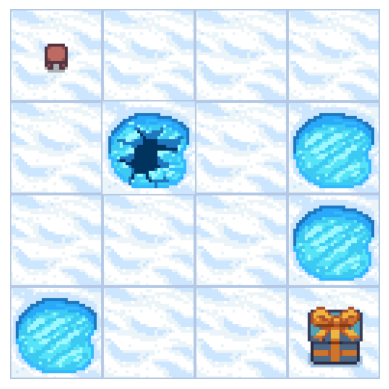

In [80]:
def run_episode(env: gym.Env) -> None:
    """
    Run a single episode in the environment using random actions.
    
    This function demonstrates basic environment interaction by resetting the
    environment and then utilizing the random policy implemented earlier to take random actions in the environment.
    The environment is rendered after each step to visualize the agent's behavior.
    
    Args:
        env: Gymnasium environment to run the episode in
    """
    # STUDENT CODE HERE (3 pts)
    env.reset()
    terminated = False
    while terminated != True:
        new_observation, reward, terminated, truncated, info = env.step(random_policy(env))
        render_env(env)

    # STUDENT CODE until HERE

run_episode(frozenlake_env)

Until now, we interacted with the environment using random actions that do not depend on the current state/observation of the environment. The agent is "blind" at the moment.

Let's look at one approach to assign "value" to each possible action in a given state to try to choose "good" actions instead of just picking one at random.

## 4.5 Introduction to Q-Learning

Q-Learning is a model-free RL algorithm that learns the optimal Q-function through experience. It basically is a table with states and actions as rows and columns.

The values in that table (Q-values) represent how good the associated action is in the given state. These values are incrementally updated using the following Q-learning update rule:
$$ Q(s,a) \leftarrow Q(s,a) + \alpha [r + \gamma \max_{a'} Q(s',a') - Q(s,a)] $$

Where:
- Q(s,a) is the Action-Value Function from last chapter which represents the expected return when choosing action a in state s
- $\alpha$ (alpha) = learning rate
- r = reward
- $\gamma$ (gamma) = discount factor
- s = current state
- s' = next state
- a = current action
- a' = best next action

The update rule is derived from the Bellman optimality equation, which, as explored earlier, expresses the relationship between the value of a state-action pair and the immediate reward plus the discounted future rewards. The algorithm incrementally adjusts the current Q-value toward the target value:

$$ r + \gamma \max_{a'} Q(s',a') $$

This ensures that over time, the Q-values reflect the expected cumulative return of taking action a in state s and following the optimal policy thereafter.

With sufficient exploration, appropriate learning rates, and a discount factor that balances short and long term rewards, Q-Learning converges towards the optimal Q-values. Once the Q-function converges, the optimal policy can be derived simply by choosing the action with the highest Q-value in each state:

$$ \pi^*(s) = \argmax_{a} Q(s,a) $$

Q-Learning is off-policy, meaning it learns the value of the optimal policy independently of the agent’s actual actions. In practice, the agent may explore using an exploratory strategy such as ϵ-greedy, but the updates always assume that the best possible next action will be taken in the future. This separation allows the algorithm to converge to the optimal policy even if the behavior policy (used for exploration) is different.

<div class="alert alert-block alert-success">
<b>Task:</b> Q-table initialization and update function
<ul>
<li> Initialize Q-table with zeros
<li> Implement the Q-learning update function
<li> The update should use the current reward and the best next action has the maximum Q-value
</ul>
</div>

In [81]:
# Initialize Q-table
q_table = np.zeros([frozenlake_env.observation_space.n, frozenlake_env.action_space.n])

def update_q_table(q_table: np.ndarray, state: int, action: int, reward: float, next_state: int, alpha: float = 0.1, gamma: float = 0.99) -> None:
    """
    Update the Q-table using the Q-learning update rule.
    
    This function implements the core Q-learning algorithm which updates the
    Q-value for a state-action pair based on the received reward and the
    maximum Q-value of the next state (Bellman equation).
    
    Args:
        q_table: Q-table where q_table[state][action] represents the Q-value
        state: Current state
        action: Action taken in the current state
        reward: Reward received after taking the action
        next_state: Next state reached after taking the action
        alpha: Learning rate (0 < alpha <= 1)
        gamma: Discount factor (0 <= gamma < 1)
    """
    # STUDENT CODE HERE (3 pts)
    q_table[state][action] += alpha*(reward + gamma*(max(q_table[next_state])) -q_table[state][action] )
    # STUDENT CODE until HERE

test.test_q_table_update(update_q_table)

Your data looks alright, you can continue with the workbook


### 4.5.1 Q Table Policy

We have a basic understanding of what a Q Table is and how we can interpret it. Now, we look into two policies that use the Q Table.

A greedy policy always chooses the action with the highest estimated value. For Q-Learning, this is the action that leads to the highest q-value for a given state.

In [82]:
def greedy_policy(q_table: np.ndarray, state: int) -> int:
    """
    A greedy policy that always selects the action with the highest Q-value.
    
    This policy exploits the current knowledge in the Q-table by always
    choosing what appears to be the best action in each state.
    
    Args:
        q_table: Q-table containing state-action values
        state: Current state
    
    Returns:
        Action with the highest Q-value in the given state
    """
    return np.argmax(q_table[state])

An epsilon-greedy policy is similar to our greedy policy from above, but we take a random action with a probability of epsilon instead of always the best action.

<div class="alert alert-block alert-success">
<b>Task:</b> Implement ε-greedy policy
<ul>
<li> With probability ε take random action (exploration)
<li> Otherwise take greedy action (exploitation)
</ul>
</div>

In [83]:
def epsilon_greedy(q_table: np.ndarray, state: int, epsilon: float) -> int:
    """
    An epsilon-greedy policy that balances exploration and exploitation.
    
    With probability epsilon, this policy explores by taking a random action.
    With probability (1-epsilon), it exploits by taking the action with the
    highest Q-value. This balance helps the agent discover better policies
    while still leveraging what it has learned.
    
    Args:
        q_table: Q-table containing state-action values
        state: Current state
        epsilon: Exploration probability (0 ≤ ε ≤ 1)
    
    Returns:
        Selected action (either random or greedy)
    """
    # STUDENT CODE HERE (2 pts)
    rng = np.random.default_rng()
    chance = rng.random()

    if(chance <= epsilon):
        return rng.integers(0, q_table.shape[1]) #max is exclusive, so it cancels out with shape
    
    return greedy_policy(q_table=q_table, state= state)
    # STUDENT CODE until HERE

<div class="alert alert-block alert-success">
<b>Question (2 pt):</b> If the action with the highest q-value is the currently known best action, what could be the benefit of not always choosing the action with the highest associated q-value during the learning process?
</div>
<div class="alert alert-block alert-success">
<b>Your Answer:</b> then we would do little to no exploration, especially when we initialize every q-value as zero. After running one episode with a positive outcome, we only explored this way, and that one would be choosen all the time. we might find the local optimum, but we are looking for the global optimum
</div>

<div class="alert alert-block alert-success">
<b>Question (2 pt):</b> In practice, this epsilon greedy policy is often combined with "epsilon decay". This means that the value of epsilon gets smaller and smaller in each episode up to a minimum value, like this:

$$ epsilon = max(0.01, epsilon * epsilon\_decay) $$

Why is epsilon decay used in practice? How could the learning process differ in comparison to not using epsilon decay?

</div>
<div class="alert alert-block alert-success">
<b>Your Answer:</b> In the beginning there is little to no information about the interaction between the environment and agent, so exploration makes sense to look for solutions in all directions. Later on some strategies cristalize as lucrative, we know the area of the global max, now converging towards it is the goal, which is why we turn down the exploration. without turning it down we would do unnessary mistakes 
</div>

## 4.6 Implementing Q-Learning

Now let's put everything together into a complete Q-learning algorithm that:
- Uses epsilon-greedy exploration
- Updates Q-values after each step
- Gradually reduces exploration (ε decay)

<div class="alert alert-block alert-success">
<b>Task:</b> Complete Q-learning algorithm
<ul>
<li> Initialize Q-table
<li> Use ε-greedy policy for action selection
<li> Update Q-values after each step
<li> Include epsilon decay over episodes (meaning the decay happens in between episodes)
</ul>
</div>

In [84]:
def q_learning(env: gym.Env, episodes: int = 10000, epsilon_start: float = 1.0, 
               epsilon_end: float = 0.01, epsilon_decay: float = 0.999) -> np.ndarray:
    """
    Implement the Q-learning algorithm to learn an optimal policy.
    
    This function trains a Q-learning agent by interacting with the environment
    over multiple episodes. It uses epsilon-greedy exploration with decay to
    balance exploration and exploitation during training.
    
    Args:
        env: Gymnasium environment to learn in
        episodes: Number of training episodes
        epsilon_start: Initial exploration probability
        epsilon_end: Minimum exploration probability
        epsilon_decay: Decay rate for exploration probability
    
    Returns:
        Learned Q-table containing state-action values
    """
    
    q_table = np.zeros([env.observation_space.n, env.action_space.n]) * 0.1
    epsilon = epsilon_start
    
    for _ in range(episodes):
        state, _ = env.reset()
        # STUDENT CODE HERE (3 pts)
        terminated = False
        truncated = False

        while not terminated and not truncated:

            action = epsilon_greedy(q_table=q_table, state=state, epsilon=epsilon)
            new_state, reward, terminated, truncated, info = env.step(action=action)
            update_q_table(q_table=q_table, state= state, action=action, reward=reward, next_state=new_state)
            state = new_state
            
            


        epsilon = max(epsilon_end, epsilon*epsilon_decay)
        

        # STUDENT CODE until HERE
        
    return q_table

test.test_q_learning(q_learning, frozenlake_env)

Your data looks alright, you can continue with the workbook


Let's have a look at the learned Q-table.

In [85]:
q_table = q_learning(frozenlake_env, episodes=10_000)
print(q_table)

[[9.41480149e-01 9.50990050e-01 9.32065335e-01 9.41480149e-01]
 [9.41480148e-01 0.00000000e+00 6.96302584e-01 8.80329154e-01]
 [3.94787957e-01 8.68602591e-01 4.00699381e-02 2.25943738e-01]
 [2.24459804e-01 0.00000000e+00 4.44745145e-03 2.76681194e-06]
 [9.50990050e-01 9.60596010e-01 0.00000000e+00 9.41480149e-01]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 9.72231222e-01 0.00000000e+00 3.45545890e-01]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [9.60596009e-01 0.00000000e+00 9.70299000e-01 9.50990049e-01]
 [9.60595977e-01 9.80100000e-01 9.80099948e-01 0.00000000e+00]
 [9.27776111e-01 9.90000000e-01 0.00000000e+00 8.54180170e-01]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 9.80099941e-01 9.90000000e-01 9.70298695e-01]
 [9.80099810e-01 9.89999971e-01 1.00000000e+00 9.80099964e-01]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.000000

<div class="alert alert-block alert-success">
<b>Question (1 pt):</b> The q-table has 5 rows (states) with only values of 0 in them. Why is that?
</div>

<div class="alert alert-block alert-success">
<b>Your Answer:</b> those are states, in which the episodes terminates. Its either a loss(ice broke) or a win. So no new q-value was learned
</div>

<div class="alert alert-block alert-success">
<b>Question (2 pt):</b> Try to explain the q-values in the seventh row and why each action has these q-values.
</div>

<div class="alert alert-block alert-success">
<b>Your Answer:</b> [0.         0.9801     0.         0.96059601], two actions(left,right) lead to termination of the episode, so the q-value is 0. The action up survives but isn't very smart so its lower(0.9605) than down(0.9801) wich is the direct way towards the goal
</div>

### 4.6.1 Q Table Visualization

Let's visualize our learned Q Learning algorithm. In this next code block, we render the best action to take as an arrow for each state/cell in the frozen lake environemnt. Have a look at the produced visualization and if your trained Q table seems reasonable.


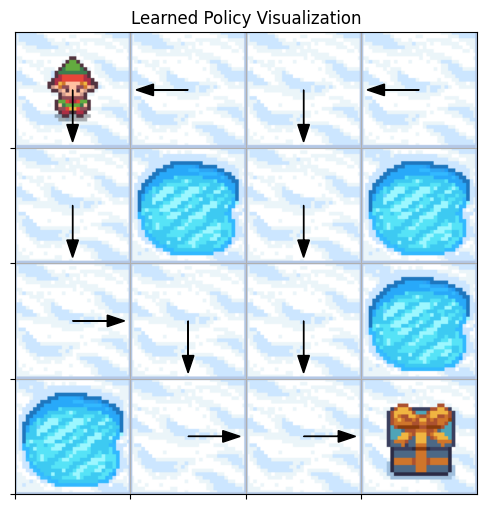

In [86]:
frozenlake_env.reset()

def visualize_policy(q_table: np.ndarray) -> None:
    """
    Visualize the learned policy from a Q-table as arrows on the grid.
    
    This function creates a graphical representation of the policy derived
    from the Q-table, showing the best action to take in each state as
    directional arrows. This helps understand what the agent has learned.
    
    Args:
        q_table: Learned Q-table containing state-action values
    """
    _, ax = plt.subplots(figsize=(6,6))
    
    ax.set_xticks(np.arange(0, 4, 1))
    ax.set_yticks(np.arange(0, 4, 1))
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.grid()
    ax.imshow(frozenlake_env.render(), extent=(0, 4, 0, 4))
    terminal = [5,7,11,12,15]
    
    for state in range(16):
        if state in terminal:
            continue
        y = state // 4
        x = state % 4
        action = np.argmax(q_table[state])
        
        dx, dy = {
            0: (-0.3, 0), # Left
            1: (0, -0.3), # Down
            2: (0.3, 0), # Right
            3: (0, 0.3) # Up
        }[action]

        y = 3 - y # origin should be top left
        ax.arrow(x + 0.5, y + 0.5, dx, dy, head_width=0.1, fc='k', ec='k')
    
    plt.title("Learned Policy Visualization")
    plt.show()

visualize_policy(q_table)

## 4.7 Evaluating Policies

Now that we have covered multiple ways of choosing actions (random policy and Q tables), let's compare their results.

<div class="alert alert-block alert-success">
<b>Task:</b> Policy evaluation
<ul>
<li> Implement functions to evaluate the success rate of the random policy and a greedy policy choosing the action with the highest q value for a given state
<li> Make sure to render the environment at each step just like at the beginning of the functions
<li> Compare their results
<li> Run multiple episodes to get reliable statistics
</ul>

Hint: These functions look very similar and only need changes in choosing the action.
</div>

In [87]:
def evaluate_random_policy(env: gym.Env, episodes: int = 1000, render: bool = False) -> float:
    """
    Evaluates the success rate of the random policy over multiple episodes.

    Args:
        env: Gymnasium environment instance.
        episodes (int): Number of episodes to evaluate.
        render (bool): Whether to render the environment during evaluation.

    Returns:
        float: Success rate of the random policy.
    """

    env.reset()
    
    if render:
        render_env(env)

    successes = 0

    # STUDENT CODE HERE (2 pts)
    for _ in range(episodes):
        terminated = False
        truncated = False
        env.reset()

        while not terminated and not truncated:
            action = random_policy(env)
            new_state, reward, terminated, truncated, info = env.step(action=action)
            state = new_state

            if render:
                render_env(env)

        if(new_state == 15): #15 is end state
            successes = successes+1

    # STUDENT CODE until HERE

    return successes / episodes

test.test_evaluate_random_policy(evaluate_random_policy, frozenlake_env)

Your data looks alright, you can continue with the workbook


In [88]:
def evaluate_q_learning(env: gym.Env, q_table: np.ndarray, episodes: int = 1000, render: bool = False) -> float:
    """
    Evaluates the success rate of the greedy Q-learning policy over multiple episodes.

    Args:
        env: Gymnasium environment instance.
        q_table (np.ndarray): Trained Q-table.
        episodes (int): Number of episodes to evaluate.
        render (bool): Whether to render the environment.

    Returns:
        float: Success rate of the Q-learning policy.
    """
    state, _ = env.reset()

    if render:
        render_env(env)
        
    successes = 0
    
    # STUDENT CODE HERE (2 pt)
    for _ in range(episodes):
        terminated = False
        truncated = False
        state, _ = env.reset()

        while not terminated and not truncated:
            action = greedy_policy(q_table=q_table, state=state)
            new_state, reward, terminated, truncated, info = env.step(action)
            state = new_state

            if render:
                render_env(env)

        if(new_state == 15): #15 is end state
            successes = successes+1

            
    # STUDENT CODE until HERE
                
    return successes / episodes

test.test_evaluate_q_learning(evaluate_q_learning, frozenlake_env, q_table)

Your data looks alright, you can continue with the workbook


In [89]:
success_rate_random = evaluate_random_policy(frozenlake_env)
print("Random policy success rate:", success_rate_random)

Random policy success rate: 0.011


In [90]:
success_rate_q_learning = evaluate_q_learning(frozenlake_env, q_table)
print("Q learing success rate:", success_rate_q_learning)

Q learing success rate: 1.0


<div class="alert alert-block alert-success">
<b>Question (2 pt):</b> Compare the policies and how they perform. Explain why the better one achieves such a result.
</div>
<div class="alert alert-block alert-success">
<b>Your Answer:</b> the random policy doesnt learn on from its mistakes. The greedy policy tries to take the otimal path, it might not be the overall most efficient, but it works
</div>

### 4.7.1 Watch your trained agent

If you want, you can use the render_env function in your evaluate functions above to view an episode of the agent using the random policy and Q learning.

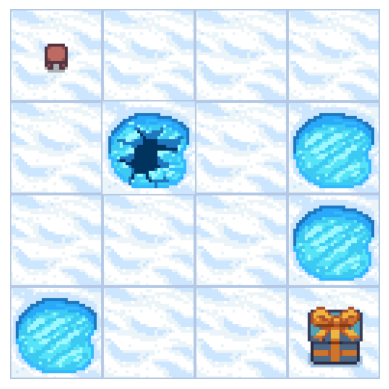

0.0

In [91]:
evaluate_random_policy(frozenlake_env, episodes=1, render=True)

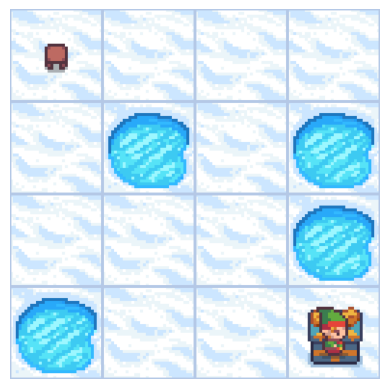

1.0

In [92]:
evaluate_q_learning(frozenlake_env, q_table, episodes=1, render=True)

### 4.7.2 It's getting slippery

To end this chapter, we will shortly look at the frozenlake environment when it is "slippery", meaning that there is a small probability that the agent moves in a random direction instead of the chosen one.

You do not have to code anything here, but take a look at the success rates and how they changed compared to the deterministic non-slippery frozenlake we had before. How do they change? Why was the performance of Q-Learning so good in the non-slippery environment?

In [93]:
slippery_env = gym.make('FrozenLake-v1', is_slippery=True)

q_table_slippery = q_learning(slippery_env, episodes=10_000)

success_rate_slippery_random = evaluate_random_policy(slippery_env)
print("Random policy success rate in slippery environment:", success_rate_slippery_random)

success_rate_slippery_q_learning = evaluate_q_learning(slippery_env, q_table_slippery)
print("Q Table success rate in slippery environment:", success_rate_slippery_q_learning)


Random policy success rate in slippery environment: 0.011
Q Table success rate in slippery environment: 0.736


# Summary

In this notebook, we explored the fundamentals of Reinforcement Learning within discrete environments, using the Frozen Lake environment from Gymnasium as a case study.

We examined how an agent interacts with its environment, the role and structure of policies, and how Q-learning employs a tabular approach to estimate state-action values based on rewards and returns.

In the subsequent notebook, we will extend these concepts to continuous environments and investigate methods for optimizing RL hyperparameters through evolutionary algorithms.